In [1]:
import numpy as np
from skimage import io, feature, color, draw, util, measure
import pandas as pd
import matplotlib.pyplot as plt

#### To add: 
1. Start new roi_id if overlap is over 2-3 frames ago. >>done
1. Fill in for when no detectable glob — either with zeroes or take measurement of most recent roi location. >>idk

In [ ]:
def detect_globular_rois(img_or_path, frame_index=0,
                         min_sigma=2, max_sigma=3, num_sigma=10,
                         threshold=0.05, overlap=0.5,
                         roi_radius=5, return_overlay=True):
    """
    Detect globular signals, draw circular ROIs around their centroids, and compute the sum intensity of pixels within.

    Args:
      img_or_path: 2D numpy array or path to a TIFF (can be a stack).
      frame_index: if img_or_path is a stack, index of frame to analyze.
      min_sigma, max_sigma, num_sigma, threshold, overlap: skimage.blob_log params.
      roi_radius: if None, radius = sqrt(2)*sigma for each blob; otherwise fixed radius in pixels.
      return_overlay: if True, also return an RGB image with circular ROI outlines.
    Returns:
      results: dataframe from list of dicts: {'y':..., 'x':..., 'radius':..., 'sum':...}
      overlay (optional): RGB image (uint8) with red ROI outlines overlaid on the analyzed frame.
    """
    if isinstance(img_or_path, (str, bytes)):
        img = io.imread(img_or_path) #file path
    else:
        img = np.asarray(img_or_path) #image matrix

    #If image is a stack (time lapse), work only on the designated frame.
    if img.ndim == 3:
        img2d = img[frame_index,:,:] #assuming (t,y,x) or (t,x,y) channel order.
    elif img.ndim == 2:
        img2d = img
    else:
        raise ValueError("Image must be 2D or 3D stack")

    #Normalize image pixel values
    img_f = util.img_as_float(img2d)/np.max(img2d)

    #Apply skimage.feature function to detect blobs using Laplacian of Gaussian.
    #Returns an array with the centroid coords of each detected blob plus the sigma of each blob.
    blobs = feature.blob_log(img_f, min_sigma=min_sigma, max_sigma=max_sigma,
                             num_sigma=num_sigma, threshold=threshold, overlap=overlap)
    results = [] #initialize results list
    #Generate overlay variable
    overlay = None
    if return_overlay:
        rgb = color.gray2rgb(util.img_as_ubyte(img_f))
        overlay = rgb.copy()

    roi_ind=0#generate ROI index to distinguish unique ROIs
    #and then plot the ROIs for each detected blob
    for y, x, sigma in blobs: #for each detected blob in this frame...
        r = (np.sqrt(2) * sigma) if roi_radius is None else roi_radius #compute radius if none is set, otherwise use given value.
        r_int = int(max(1, round(r))) #radius must be an integer value of pixels greater than or equal to one. 
        rr, cc = draw.disk((y, x), r_int, shape=img_f.shape) #generate a disk mask about each given centroid.
        sum_intensity = float(img_f[rr, cc].sum()) #sum all pixel intensities within said disk.
        avg_intensity = sum_intensity/(img_f.shape[0]*img_f.shape[1])
        results.append({'ROI_ID': roi_ind,'frame':frame_index,'y': float(y), 'x': float(x), 'radius': float(r), 'sum': sum_intensity, 'avg': avg_intensity}) #append the summed intensity and other relevant metrics to the results dictionary.
        if return_overlay: #if overlay requested...
            pr, pc = draw.circle_perimeter(int(round(y)), int(round(x)), r_int, shape=overlay.shape[:2]) #draw the circular ROIs around the glob centroids.
            overlay[pr, pc] = (255, 0, 0) #sets color of ROI circles using RGB values.
        roi_ind+=1 #update ROI index
    if return_overlay==True: #if overlay requested...
        io.imshow(overlay)
        return pd.DataFrame.from_dict(results), overlay, rr, cc #return it with results
    return pd.DataFrame.from_dict(results) #else just return results. 

def roi_overlap(x1,y1,x2,y2, roi_radius=5, shape=(512,512)): 
    """
    Args: Two sets of x-y centroid coords, roi radius paramter, and total shape of masks (manually set to same as image)
    Outputs: Fractional overlap between disks of equal radius centered about each centroid given.
    """

    if np.absolute(x1-x2)>(2*roi_radius) or np.absolute(y1-y2)>(2*roi_radius): #If overlap impossible, don't bother.
        frac_olap=0
    else: #otherwise, do the overlap calculation
        rr1, cc1 = draw.disk((y1, x1), roi_radius, shape=shape) #generate a disk mask about first centroid; variables contain pixel coords.
        dummy1=np.ones(shape) #dummy array for overlap measure
        dummy1[rr1,cc1]=-1 #set ROI pixel values to -1
        mask1=dummy1<0 #Apply Boolean statement such that ROI pixels become Trues and all else become Falses.
        rr2, cc2 = draw.disk((y2, x2), roi_radius, shape=shape) #generate a disk mask about second centroid; variables contain pixel coords.
        dummy2=np.ones(shape) #dummy array for overlap measure
        dummy2[rr2,cc2]=-1 #set ROI pixel values to -1
        mask2=dummy2<0 #Apply Boolean statement such that ROI pixels become Trues and all else become Falses.
        frac_olap=measure.intersection_coeff(mask1, mask2) #measure fractional overlap of Boolean ROI masks.
    return frac_olap

def analyze_budnecks(img_or_path, olap_thresh=0.2):
    """
    Args: Image matrix or path to image file
    Outputs: Dataframe consisting of roi id, frame number, x-y centroid coords, roi radius, and sum pixel intensity w/in roi
    for each detected globular signal within each frame of time lapse. 
    """
    
    if isinstance(img_or_path, (str, bytes)):
        img = io.imread(img_or_path) #file path
    else:
        img = np.asarray(img_or_path) #image matrix
    
    for i in range(img.shape[0]): #for each frame in timelapse...
        print('processing frame '+str(i)+'/'+str(np.max(img.shape[0])-1)) #optional frame by frame progress update
        if i==0: #for first frame, run initial globular detection and record ROIs and other metrics.
            running_list=detect_globular_rois(img, frame_index=i, return_overlay=False) #dataframe containing metrics for frame_0
        else: #for each frame past the first...
            cand_globs=detect_globular_rois(img, frame_index=i, return_overlay=False) #detect signal candidates in new frame.
            id_ind=1 #reset dummy id index value to use when assigning new, unique roi_ids to new signals.

            for cand_idx in cand_globs.index:
                candx, candy = cand_globs.iloc[cand_idx]['x'], cand_globs.iloc[cand_idx]['y'] #extract centroid coords of candidate ROI
                overlap_ids, overlaps=[],[] #initialize lists for overlap comparison

                for estb_id in np.unique(running_list['ROI_ID'].values): #for each preexisting ROI...
                    estb_mask=running_list['ROI_ID'].values==estb_id #generate mask of its dataframe row
                    estbx, estby = running_list[estb_mask]['x'].values[-1], running_list[estb_mask]['y'].values[-1] #extract most recent centroid coords of established ROI
                    overlap=roi_overlap(candx,candy,estbx,estby) #calculate fractional overlap between candidate roi and each previous one.
                    if overlap>=olap_thresh and cand_globs.iloc[cand_idx]['frame']-running_list[estb_mask]['frame'].values[-1]<3: #if overlap has sufficient fraction and is with recent-enough roi...
                        overlap_ids.append(estb_id)
                        overlaps.append(overlap)
                    else: #otherwise, move along through the rest of the established rois.
                        continue #move along, move along like i know ya do. move along, move along just to make it through
                if len(overlap_ids)>0: #if at least one overlap option
                    cand_globs.loc[cand_globs.index==cand_idx, 'ROI_ID']=overlap_ids[overlaps.index(np.max(overlaps))] #reassign candidate roi_id to that of established roi with max overlap
                else: #if insufficient overlap with preexisting signals...
                    cand_globs.loc[cand_globs.index==cand_idx, 'ROI_ID']=(np.max(running_list['ROI_ID'].values)+id_ind) #assign new id to accepted source
                    id_ind+=1 #update dummy id index to reflect new signal recognized.
            
            running_list=pd.concat([running_list,cand_globs], ignore_index=True) #append this frame's information to running list of dictionaries.
    return running_list

def analyze_signal(df, roi_ind, metric, plot_graph=False):
    """
    Args: Dataframe (or its corresponding file path) containing at least roi ids, frame numbers, and desired metric(s) to plot. Optional Boolean arg to generate plot.
    Outputs: Dataframe containing roi ids and desired accompanying metrics. Optional plot.
    """
    if plot_graph==True:
        plt.figure()
        for roi in np.unique(df['ROI_ID'].values)[roi_ind:roi_ind+1]: #for each detected roi in entire time lapse...
            mask=df['ROI_ID'].values==roi #create a mask to extract roi's rows
            roi_subset=df[mask] #apply mask
            plt.plot(roi_subset['frame'].values,roi_subset[metric].values/np.max(roi_subset[metric].values)) #plots desired metric as function of frame (proxy for time)
            plt.scatter(roi_subset['frame'].values,roi_subset[metric].values/np.max(roi_subset[metric].values), label='Roi_'+str(roi))
        plt.xlabel('Time (min)')
        # plt.ylabel('Normalized Sum Interior Pixel Intensity (AU)')
    return df

def roi_paths(df, roi_id, roi_radius=5, img_dim_x=512, img_dim_y=512):
    """
    Args: Dataframe containing the (x,y) coords of roi(s) to visualize for each frame detected, ID of roi to display, radius of roi disk. 
    Outputs: Plot/image depicting the path of roi centroids and/or disks in coordinate space. 
    """
    id_mask=df['ROI_ID'].values==roi_id #generate mask for rows with roi_id matching that of argument
    rx, ry = df[id_mask]['x'].values, df[id_mask]['y'].values #extract centroid coords of candidate ROI
    plt.figure()
    plt.scatter(rx,ry, label='ROI Centroids') #plot centroids as scatter plot
    plt.xlim(0,img_dim_x) #set axes limits to correspond to those of image
    plt.ylim(0,img_dim_y)
    plt.legend() #show legend

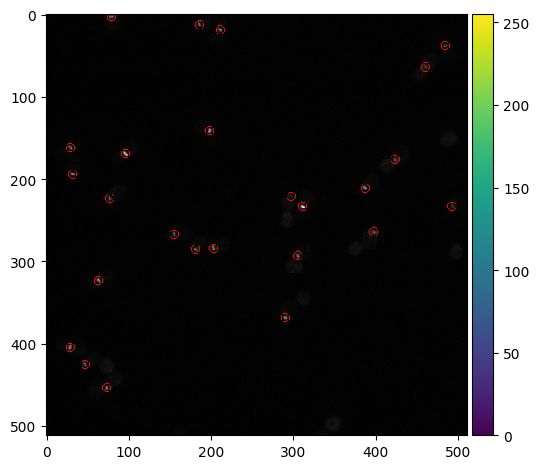

In [120]:
tdf,toverlay,trr,tcc=detect_globular_rois(r'C:\Users\jglic\Downloads\Run_2\SUM_20251212_yfp-216nm_Run-2.tif')

In [49]:
# overlay_stack=[]
# for frame in np.arange(0,21):
#     tdf,toverlay,trr,tcc=detect_globular_rois(r'C:\Users\jglic\Downloads\Run_2\SUM_20251212_yfp-216nm_Run-2.tif', frame_index=frame)
#     overlay_stack.append(toverlay)
# ind=0
# io.imshow(overlay_stack[ind])
# ind+=3

In [176]:
test=analyze_budnecks(r'C:\Users\jglic\Downloads\Run_2\SUM_20251212_yfp-216nm_Run-2.tif')

processing frame 0/21
processing frame 1/21
processing frame 2/21
processing frame 3/21
processing frame 4/21
processing frame 5/21
processing frame 6/21
processing frame 7/21
processing frame 8/21
processing frame 9/21
processing frame 10/21
processing frame 11/21
processing frame 12/21
processing frame 13/21
processing frame 14/21
processing frame 15/21
processing frame 16/21
processing frame 17/21
processing frame 18/21
processing frame 19/21
processing frame 20/21
processing frame 21/21


In [177]:
test.to_csv(r'C:\Users\jglic\Downloads\Run_2\signal-analysis_20251212.csv', index=False)

In [178]:
df_20251212=pd.read_csv(r'C:\Users\jglic\Downloads\Run_2\signal-analysis_20251212.csv')

In [184]:
df_20251212.loc[df_20251212.ROI_ID==3]
# test.loc[test.ROI_ID==0]

,ROI_ID,frame,y,x,radius,sum,avg
3,3,0,195.0,32.0,5.0,8.966282,0.000034
31,3,1,194.0,33.0,5.0,9.379590,0.000036
60,3,2,194.0,33.0,5.0,10.275997,0.000039
81,3,3,194.0,34.0,5.0,12.102151,0.000046
107,3,4,194.0,35.0,5.0,12.778037,0.000049
135,3,5,194.0,36.0,5.0,11.510380,0.000044
170,3,6,193.0,36.0,5.0,12.651273,0.000048
202,3,7,191.0,37.0,5.0,11.326178,0.000043
232,3,8,191.0,38.0,5.0,13.831810,0.000053
262,3,9,191.0,39.0,5.0,11.341513,0.000043


In [ ]:
dind=0

3

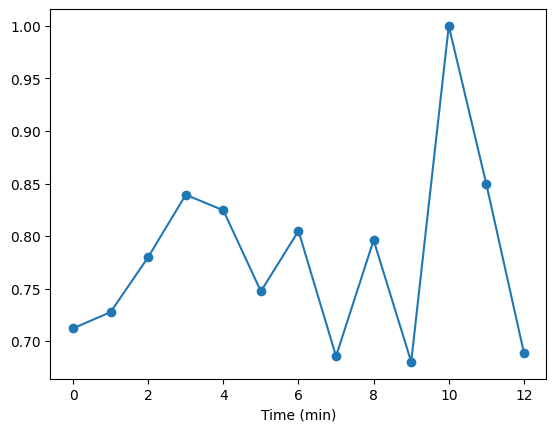

In [183]:
df=analyze_signal(df_20251212, roi_ind=dind,metric='avg', plot_graph=True)
dind+=1

Average background pixel intensity of 20. Average Roi average pixel intensity 250 at start, 85 at end.

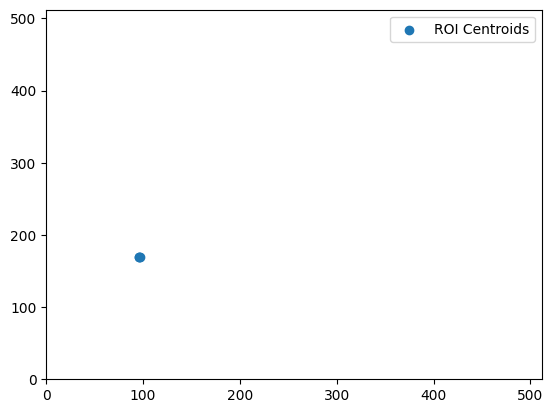

In [147]:
# roi_paths(df_20251212, 5)
roi_paths(test, 1)